# 03 - Classificação e Avaliação

## Objetivo
Treinar, avaliar e comparar classificadores clássicos para identificar defeitos em grãos de café.

### Classificadores:
1. **SVM** (Support Vector Machine)
2. **Random Forest**
3. **KNN** (K-Nearest Neighbors)

### Métricas:
- Acurácia, Precisão, Recall, F1-Score
- Matriz de Confusão
- Validação cruzada

### Cuidados:
- Divisão estratificada treino/validação/teste
- StandardScaler ajustado apenas no treino (sem vazamento)
- random_state fixo para reprodutibilidade

In [21]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA

RANDOM_STATE = 42

# Caminhos
PROJECT_ROOT = Path(r'c:\Projeto_Visao_Comp')
OUTPUT_DIR = PROJECT_ROOT / 'outputs'

# Carregar dados
X = pd.read_csv(str(OUTPUT_DIR / 'X.csv'))
y = pd.read_csv(str(OUTPUT_DIR / 'y.csv'))['class']

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'Classes: {y.nunique()}')
print(f'\nDistribuição:')
print(y.value_counts())

X shape: (979, 29)
y shape: (979,)
Classes: 17

Distribuição:
class
Immature                 78
Full Sour                75
Fungus Damange           75
Cut                      66
Partial Black            65
Broken                   62
Severe Insect Damange    57
Shell                    57
Slight Insect Damage     55
Dry Cherry               54
Parchment                54
Withered                 54
Husk                     53
Partial Sour             50
Floater                  48
Full Black               41
Fade                     35
Name: count, dtype: int64


## Divisão dos dados: Treino / Validação / Teste

Usamos divisão estratificada para manter a proporção das classes em cada conjunto:
- **Treino**: 60%
- **Validação**: 20%
- **Teste**: 20%

In [22]:
# Codificar labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_names = le.classes_

# Divisão treino+val / teste (80/20)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y_encoded, test_size=0.20, random_state=RANDOM_STATE, stratify=y_encoded
)

# Divisão treino / val (75/25 do train_val = 60/20 do total)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=RANDOM_STATE, stratify=y_train_val
)

print(f'Treino:    {X_train.shape[0]} amostras ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Validação: {X_val.shape[0]} amostras ({X_val.shape[0]/len(X)*100:.0f}%)')
print(f'Teste:     {X_test.shape[0]} amostras ({X_test.shape[0]/len(X)*100:.0f}%)')

Treino:    587 amostras (60%)
Validação: 196 amostras (20%)
Teste:     196 amostras (20%)


In [23]:
# Normalização - Ajustar APENAS no treino (evitar vazamento de dados)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print('StandardScaler ajustado no conjunto de treino e aplicado em val/teste.')
print(f'Média do treino (primeiras 5 features): {scaler.mean_[:5].round(2)}')
print(f'Desvio do treino (primeiras 5 features): {scaler.scale_[:5].round(2)}')

StandardScaler ajustado no conjunto de treino e aplicado em val/teste.
Média do treino (primeiras 5 features): [3.204077e+04 7.214500e+02 7.600000e-01 9.700000e-01 7.300000e-01]
Desvio do treino (primeiras 5 features): [1.4193e+04 1.8058e+02 1.2000e-01 3.0000e-02 6.0000e-02]


## Treinamento dos classificadores

### Classificador 1: SVM (Support Vector Machine)

In [24]:
# SVM com kernel RBF
svm_clf = SVC(kernel='rbf', C=10, gamma='scale', random_state=RANDOM_STATE)
svm_clf.fit(X_train_scaled, y_train)

# Avaliar no conjunto de validação
y_val_pred_svm = svm_clf.predict(X_val_scaled)
print('=== SVM (RBF) - Validação ===')
print(f'Acurácia: {accuracy_score(y_val, y_val_pred_svm):.4f}')
print(f'F1 (macro): {f1_score(y_val, y_val_pred_svm, average="macro"):.4f}')

=== SVM (RBF) - Validação ===
Acurácia: 0.6122
F1 (macro): 0.6173


### Classificador 2: Random Forest

In [25]:
# Random Forest
rf_clf = RandomForestClassifier(
    n_estimators=200, max_depth=None, min_samples_split=5,
    random_state=RANDOM_STATE, n_jobs=-1
)
rf_clf.fit(X_train_scaled, y_train)

y_val_pred_rf = rf_clf.predict(X_val_scaled)
print('=== Random Forest - Validação ===')
print(f'Acurácia: {accuracy_score(y_val, y_val_pred_rf):.4f}')
print(f'F1 (macro): {f1_score(y_val, y_val_pred_rf, average="macro"):.4f}')

=== Random Forest - Validação ===
Acurácia: 0.6429
F1 (macro): 0.6319


### Classificador 3: KNN

In [26]:
# KNN
knn_clf = KNeighborsClassifier(n_neighbors=7, weights='distance', n_jobs=-1)
knn_clf.fit(X_train_scaled, y_train)

y_val_pred_knn = knn_clf.predict(X_val_scaled)
print('=== KNN (k=7) - Validação ===')
print(f'Acurácia: {accuracy_score(y_val, y_val_pred_knn):.4f}')
print(f'F1 (macro): {f1_score(y_val, y_val_pred_knn, average="macro"):.4f}')

=== KNN (k=7) - Validação ===
Acurácia: 0.5663
F1 (macro): 0.5800


## Validação Cruzada (5-fold estratificada)

=== Validação Cruzada (5-fold) ===
SVM (RBF)      : F1 = 0.6140 ± 0.0258
Random Forest  : F1 = 0.6510 ± 0.0425
KNN (k=7)      : F1 = 0.5185 ± 0.0349


C:\Users\JoãoAntoniodeSouzaVi\AppData\Local\Temp\ipykernel_13244\3917392736.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(cv_results.values(), labels=cv_results.keys())


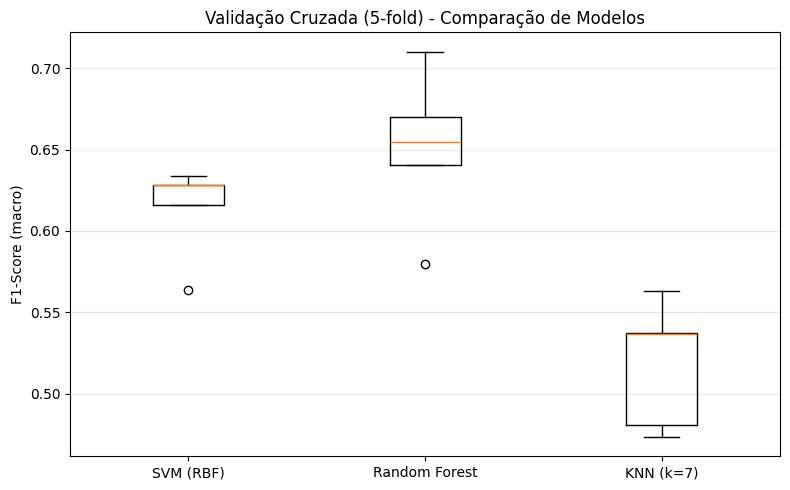

In [27]:
# Validação cruzada no conjunto treino+val
X_trainval_scaled = scaler.fit_transform(X_train_val)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

modelos = {
    'SVM (RBF)': SVC(kernel='rbf', C=10, gamma='scale', random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=200, min_samples_split=5, random_state=RANDOM_STATE, n_jobs=-1),
    'KNN (k=7)': KNeighborsClassifier(n_neighbors=7, weights='distance', n_jobs=-1)
}

print('=== Validação Cruzada (5-fold) ===')
cv_results = {}
for name, model in modelos.items():
    scores = cross_val_score(model, X_trainval_scaled, y_train_val, cv=cv, scoring='f1_macro')
    cv_results[name] = scores
    print(f'{name:15s}: F1 = {scores.mean():.4f} ± {scores.std():.4f}')

# Boxplot da validação cruzada
plt.figure(figsize=(8, 5))
plt.boxplot(cv_results.values(), labels=cv_results.keys())
plt.ylabel('F1-Score (macro)')
plt.title('Validação Cruzada (5-fold) - Comparação de Modelos')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'validacao_cruzada.png'), dpi=150, bbox_inches='tight')
plt.show()

## Ajuste de Hiperparâmetros (GridSearchCV)

Busca exaustiva dos melhores hiperparâmetros usando validação cruzada estratificada no conjunto treino+validação.

In [28]:
from sklearn.model_selection import GridSearchCV

# Grids de busca
param_grids = {
    'SVM (RBF)': {
        'model': SVC(kernel='rbf', random_state=RANDOM_STATE),
        'params': {
            'C': [0.1, 1, 10, 100],
            'gamma': ['scale', 'auto', 0.01, 0.001]
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [None, 10, 20],
            'min_samples_split': [2, 5, 10]
        }
    },
    'KNN': {
        'model': KNeighborsClassifier(n_jobs=-1),
        'params': {
            'n_neighbors': [3, 5, 7, 11, 15],
            'weights': ['uniform', 'distance']
        }
    }
}

print('=== GridSearchCV (5-fold estratificado) ===\n')
best_params = {}
for name, config in param_grids.items():
    grid = GridSearchCV(
        config['model'], config['params'],
        cv=cv, scoring='f1_macro', n_jobs=-1, refit=True
    )
    grid.fit(X_trainval_scaled, y_train_val)
    best_params[name] = grid.best_params_
    print(f'{name}:')
    print(f'  Melhor F1 (CV): {grid.best_score_:.4f}')
    print(f'  Melhores params: {grid.best_params_}\n')

print('Hiperparâmetros otimizados serão usados na avaliação final.')

=== GridSearchCV (5-fold estratificado) ===

SVM (RBF):
  Melhor F1 (CV): 0.6335
  Melhores params: {'C': 10, 'gamma': 0.01}

Random Forest:
  Melhor F1 (CV): 0.6562
  Melhores params: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}

KNN:
  Melhor F1 (CV): 0.5341
  Melhores params: {'n_neighbors': 15, 'weights': 'distance'}

Hiperparâmetros otimizados serão usados na avaliação final.


## Avaliação Final no Conjunto de Teste

Re-treinar os modelos no conjunto treino+validação com os melhores hiperparâmetros e avaliar no teste (reservado apenas para avaliação final).

In [29]:
# Re-ajustar scaler em treino+val, aplicar no teste
scaler_final = StandardScaler()
X_trainval_final = scaler_final.fit_transform(X_train_val)
X_test_final = scaler_final.transform(X_test)

# Treinar modelos finais com melhores hiperparâmetros
svm_final = SVC(kernel='rbf', random_state=RANDOM_STATE, **best_params['SVM (RBF)'])
svm_final.fit(X_trainval_final, y_train_val)

rf_final = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, **best_params['Random Forest'])
rf_final.fit(X_trainval_final, y_train_val)

knn_final = KNeighborsClassifier(n_jobs=-1, **best_params['KNN'])
knn_final.fit(X_trainval_final, y_train_val)

# Predições no teste
y_test_pred_svm = svm_final.predict(X_test_final)
y_test_pred_rf = rf_final.predict(X_test_final)
y_test_pred_knn = knn_final.predict(X_test_final)

print('Modelos treinados em treino+validação e avaliados no teste.')

Modelos treinados em treino+validação e avaliados no teste.


In [30]:
# Tabela comparativa final
def calcular_metricas(y_true, y_pred, nome):
    return {
        'Modelo': nome,
        'Acurácia': accuracy_score(y_true, y_pred),
        'Precisão (macro)': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'Recall (macro)': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'F1 (macro)': f1_score(y_true, y_pred, average='macro', zero_division=0)
    }

resultados = pd.DataFrame([
    calcular_metricas(y_test, y_test_pred_svm, 'SVM (RBF)'),
    calcular_metricas(y_test, y_test_pred_rf, 'Random Forest'),
    calcular_metricas(y_test, y_test_pred_knn, 'KNN (k=7)')
])

print('\n========== TABELA COMPARATIVA FINAL (TESTE) ==========')
print(resultados.to_string(index=False, float_format='%.4f'))

# Salvar tabela
resultados.to_csv(str(OUTPUT_DIR / 'tabela_metricas.csv'), index=False)
print(f'\nTabela salva em: {OUTPUT_DIR / "tabela_metricas.csv"}')


========== TABELA COMPARATIVA FINAL (TESTE) ==========
       Modelo  Acurácia  Precisão (macro)  Recall (macro)  F1 (macro)
    SVM (RBF)    0.6582            0.6688          0.6495      0.6521
Random Forest    0.6276            0.6132          0.6164      0.6009
    KNN (k=7)    0.5510            0.6141          0.5402      0.5370

Tabela salva em: c:\Projeto_Visao_Comp\outputs\tabela_metricas.csv


## Matrizes de Confusão

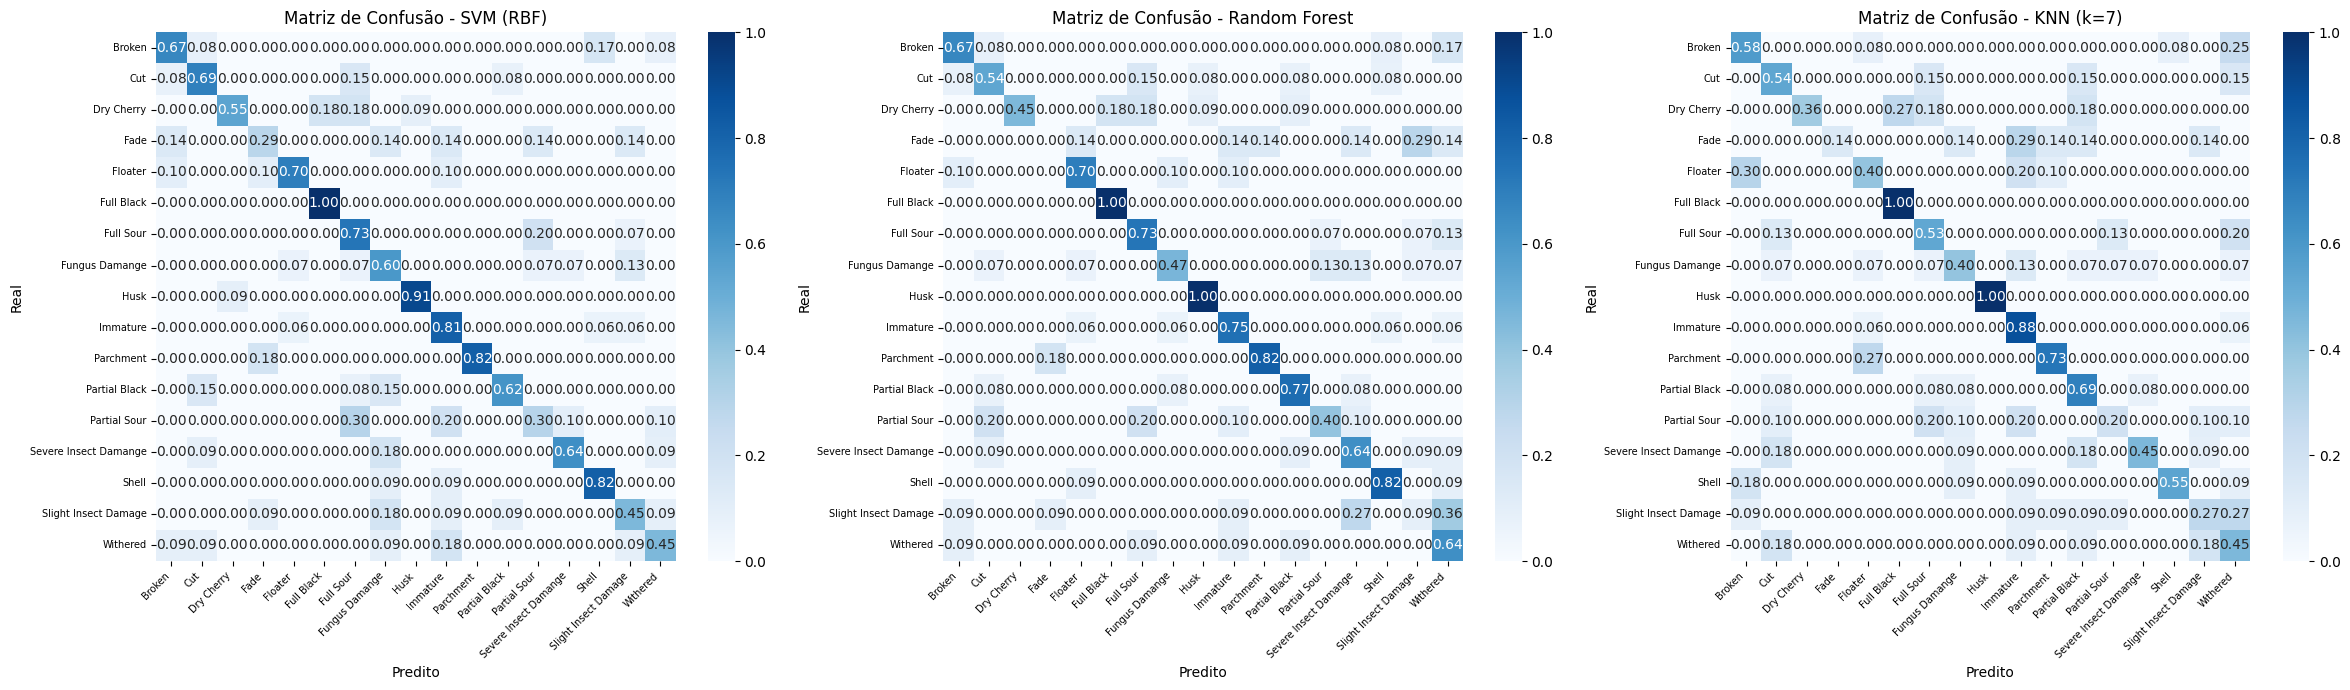

In [31]:
# Matrizes de confusão para cada modelo
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

modelos_pred = [
    ('SVM (RBF)', y_test_pred_svm),
    ('Random Forest', y_test_pred_rf),
    ('KNN (k=7)', y_test_pred_knn)
]

for i, (nome, y_pred) in enumerate(modelos_pred):
    cm = confusion_matrix(y_test, y_pred)
    # Normalizar por linha (percentual)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[i], vmin=0, vmax=1)
    axes[i].set_title(f'Matriz de Confusão - {nome}')
    axes[i].set_xlabel('Predito')
    axes[i].set_ylabel('Real')
    axes[i].set_xticklabels(class_names, rotation=45, ha='right', fontsize=7)
    axes[i].set_yticklabels(class_names, rotation=0, fontsize=7)

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'matrizes_confusao.png'), dpi=150, bbox_inches='tight')
plt.show()

## Classification Report detalhado (melhor modelo)

In [32]:
# Report detalhado do melhor modelo
melhor_idx = resultados['F1 (macro)'].idxmax()
melhor_nome = resultados.loc[melhor_idx, 'Modelo']
melhor_pred = [y_test_pred_svm, y_test_pred_rf, y_test_pred_knn][melhor_idx]

print(f'\n=== Classification Report - {melhor_nome} (Melhor Modelo) ===')
print(classification_report(y_test, melhor_pred, target_names=class_names, zero_division=0))


=== Classification Report - SVM (RBF) (Melhor Modelo) ===
                       precision    recall  f1-score   support

               Broken       0.67      0.67      0.67        12
                  Cut       0.64      0.69      0.67        13
           Dry Cherry       0.86      0.55      0.67        11
                 Fade       0.33      0.29      0.31         7
              Floater       0.78      0.70      0.74        10
           Full Black       0.80      1.00      0.89         8
            Full Sour       0.55      0.73      0.63        15
       Fungus Damange       0.50      0.60      0.55        15
                 Husk       0.91      0.91      0.91        11
             Immature       0.62      0.81      0.70        16
            Parchment       1.00      0.82      0.90        11
        Partial Black       0.80      0.62      0.70        13
         Partial Sour       0.38      0.30      0.33        10
Severe Insect Damange       0.78      0.64      0.70      

## Análise de Importância das Features (Random Forest)

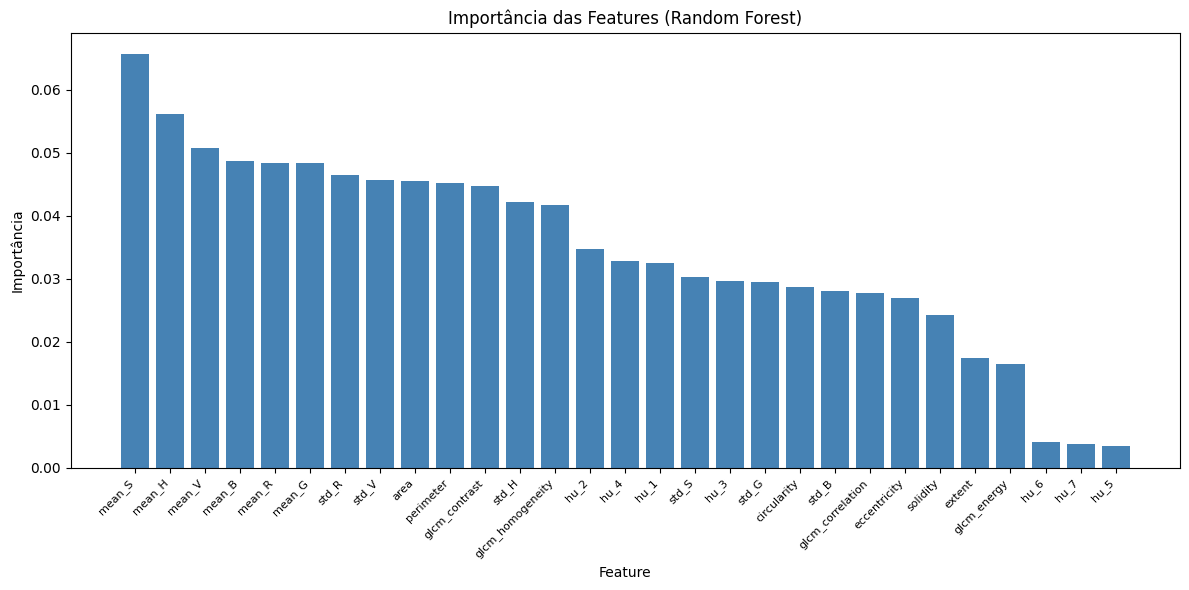


Top 10 features mais importantes:
  1. mean_S: 0.0657
  2. mean_H: 0.0562
  3. mean_V: 0.0508
  4. mean_B: 0.0487
  5. mean_R: 0.0484
  6. mean_G: 0.0484
  7. std_R: 0.0465
  8. std_V: 0.0457
  9. area: 0.0455
  10. perimeter: 0.0452


In [33]:
# Importância das features pelo Random Forest
feature_names = X.columns.tolist()
importances = rf_final.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.bar(range(len(importances)), importances[indices], color='steelblue')
plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=45, ha='right', fontsize=8)
plt.title('Importância das Features (Random Forest)')
plt.xlabel('Feature')
plt.ylabel('Importância')
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'importancia_features_rf.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 10 features mais importantes:')
for i in range(10):
    print(f'  {i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.4f}')

## SelectKBest - Seleção de Features

Features selecionadas (top 15 por ANOVA):
  - area
  - hu_1
  - hu_2
  - mean_B
  - mean_G
  - std_G
  - mean_R
  - std_R
  - std_H
  - mean_S
  - mean_V
  - std_V
  - glcm_contrast
  - glcm_homogeneity
  - glcm_correlation


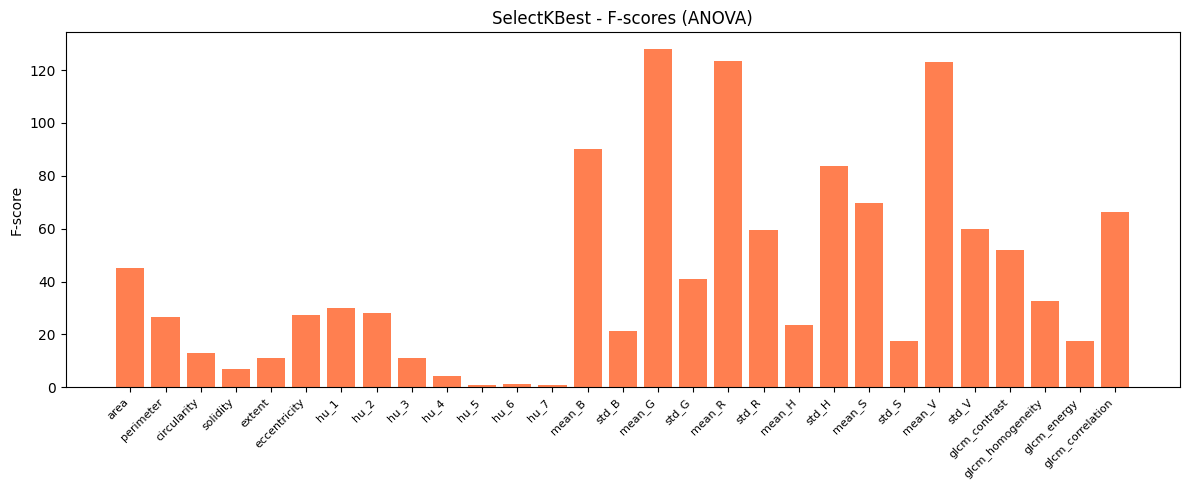

In [34]:
# SelectKBest com ANOVA F-value
selector = SelectKBest(f_classif, k=15)
X_train_selected = selector.fit_transform(X_trainval_final, y_train_val)
X_test_selected = selector.transform(X_test_final)

# Quais features foram selecionadas?
selected_mask = selector.get_support()
selected_features = [feature_names[i] for i in range(len(feature_names)) if selected_mask[i]]
print(f'Features selecionadas (top 15 por ANOVA):')
for f in selected_features:
    print(f'  - {f}')

# Scores
scores = selector.scores_
plt.figure(figsize=(12, 5))
plt.bar(feature_names, scores, color='coral')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.title('SelectKBest - F-scores (ANOVA)')
plt.ylabel('F-score')
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'selectkbest_scores.png'), dpi=150, bbox_inches='tight')
plt.show()

## PCA - Visualização em 2D

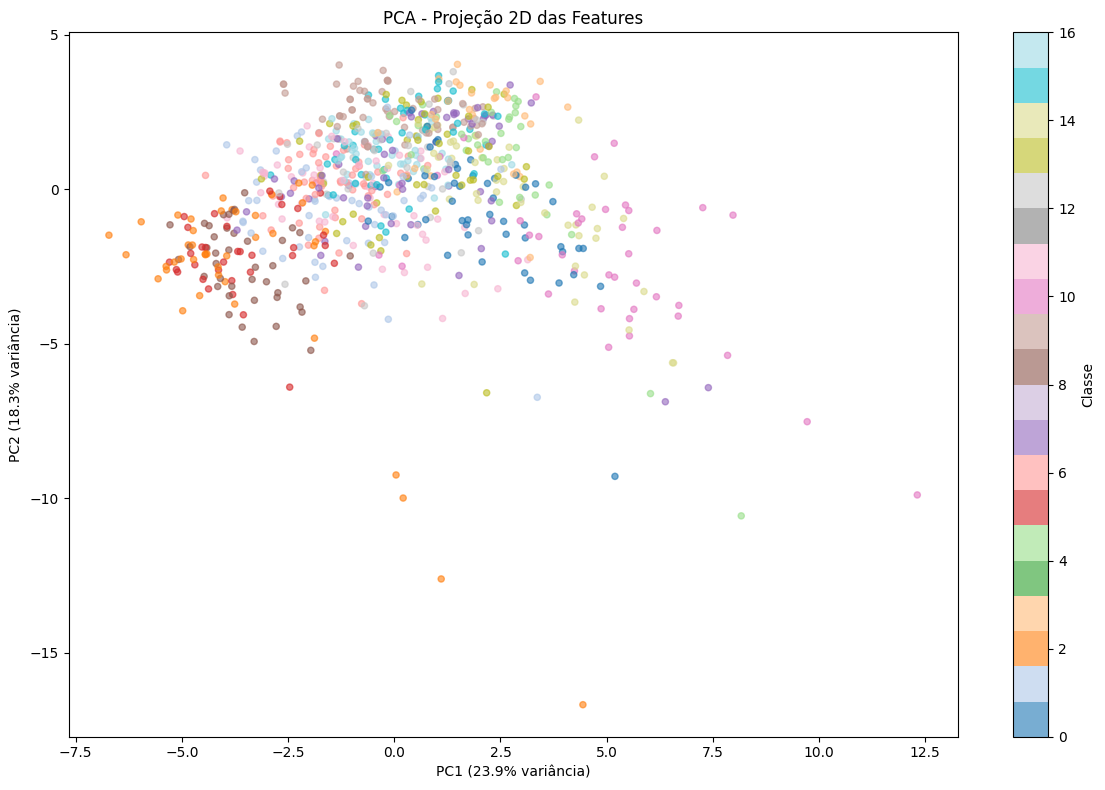

Variância explicada: PC1=23.9%, PC2=18.3%
Total: 42.2%


In [35]:
# PCA para visualização
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_trainval_final)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train_val, cmap='tab20', alpha=0.6, s=20)
plt.colorbar(scatter, label='Classe')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variância)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variância)')
plt.title('PCA - Projeção 2D das Features')
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'pca_2d.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'Variância explicada: PC1={pca.explained_variance_ratio_[0]*100:.1f}%, PC2={pca.explained_variance_ratio_[1]*100:.1f}%')
print(f'Total: {sum(pca.explained_variance_ratio_)*100:.1f}%')

## Análise de Erros

Identificar imagens mal classificadas e formular hipóteses sobre o porquê.

In [36]:
# Identificar erros do melhor modelo no teste
erros_mask = y_test != melhor_pred
n_erros = erros_mask.sum()
n_total = len(y_test)
print(f'Total de erros: {n_erros}/{n_total} ({n_erros/n_total*100:.1f}%)')

# Classes mais confundidas
cm = confusion_matrix(y_test, melhor_pred)
np.fill_diagonal(cm, 0)  # Zerar diagonal para ver apenas erros

print(f'\nPares de classes mais confundidos:')
# Top 5 confusões
for _ in range(5):
    i, j = np.unravel_index(cm.argmax(), cm.shape)
    if cm[i, j] == 0:
        break
    print(f'  {class_names[i]} confundido com {class_names[j]}: {cm[i, j]} vezes')
    cm[i, j] = 0

Total de erros: 67/196 (34.2%)

Pares de classes mais confundidos:
  Full Sour confundido com Partial Sour: 3 vezes
  Partial Sour confundido com Full Sour: 3 vezes
  Broken confundido com Shell: 2 vezes
  Cut confundido com Full Sour: 2 vezes
  Dry Cherry confundido com Full Black: 2 vezes


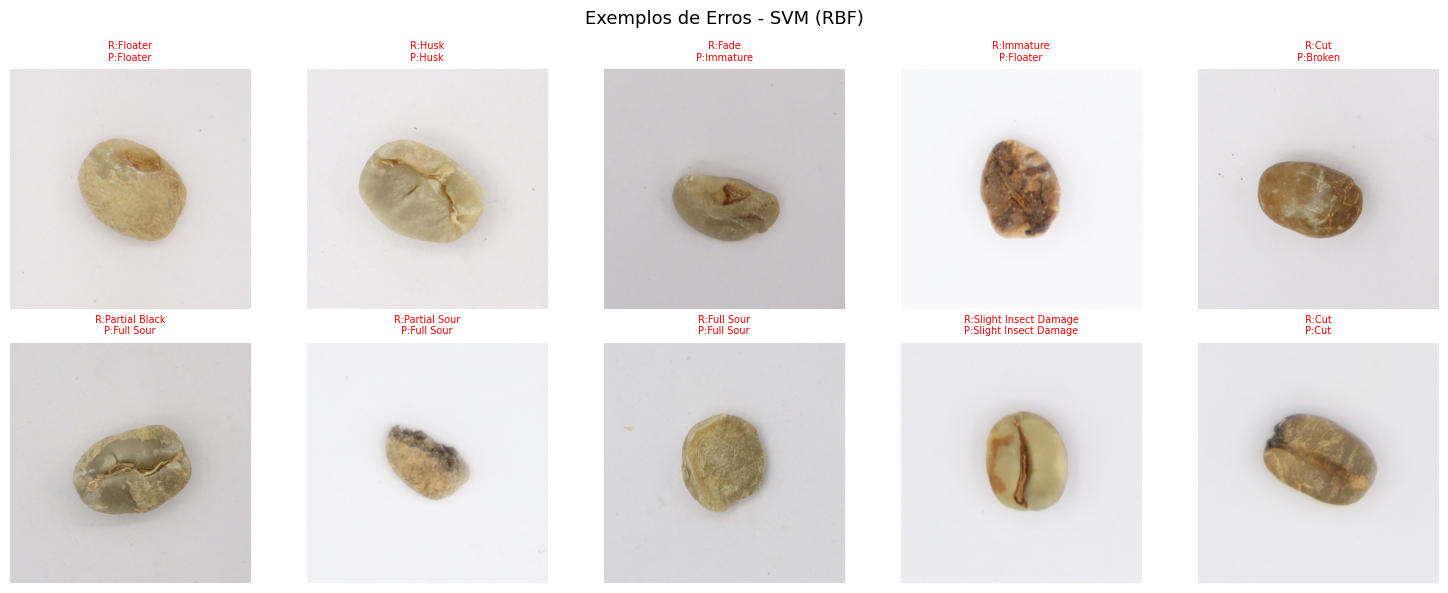

In [37]:
# Visualizar exemplos de erros
import cv2

DATASET_DIR = PROJECT_ROOT / 'archive'

# Reconstruir mapeamento de índices
all_paths = []
all_labels_list = []
classes_sorted = sorted([d for d in os.listdir(DATASET_DIR) if (DATASET_DIR / d).is_dir()])
for cls in classes_sorted:
    for img_path in sorted((DATASET_DIR / cls).glob('*.jpg')):
        all_paths.append(img_path)
        all_labels_list.append(cls)

# Índices do teste
test_indices = X_test.index.tolist()
erro_indices = [test_indices[i] for i in range(len(y_test)) if erros_mask[i]]

# Mostrar até 10 erros
n_show = min(10, len(erro_indices))
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for i in range(n_show):
    idx = erro_indices[i]
    if idx < len(all_paths):
        img = cv2.imread(str(all_paths[idx]))
        if img is not None:
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            axes[i].imshow(img_rgb)
        
        real_label = class_names[y_test[i] if isinstance(y_test, np.ndarray) else y_test.iloc[i]]
        pred_label = class_names[melhor_pred[i]]
        axes[i].set_title(f'R:{real_label}\nP:{pred_label}', fontsize=7, color='red')
    axes[i].axis('off')

# Ocultar eixos extras
for i in range(n_show, 10):
    axes[i].axis('off')

plt.suptitle(f'Exemplos de Erros - {melhor_nome}', fontsize=13)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'analise_erros.png'), dpi=150, bbox_inches='tight')
plt.show()

## Comparação entre grupos de features

Treinar o melhor modelo usando apenas subconjuntos de features para entender a contribuição de cada grupo.

=== Comparação entre Grupos de Features (SVM) ===
        Grupo  N_features  Acurácia  F1 (macro)
        Forma           6    0.3571      0.3334
           Hu           7    0.1582      0.1163
          Cor          12    0.6020      0.5882
      Textura           4    0.4439      0.4076
Cor + Textura          16    0.6582      0.6324
        Todas          29    0.6276      0.6105


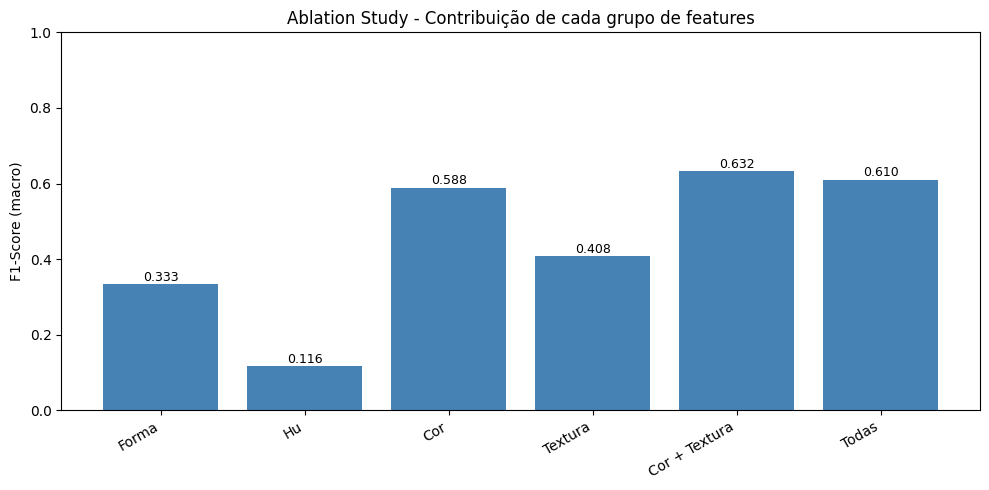

In [38]:
# Ablation: comparar grupos de features
feature_groups = {
    'Forma': ['area', 'perimeter', 'circularity', 'solidity', 'extent', 'eccentricity'],
    'Hu': [f'hu_{i}' for i in range(1, 8)],
    'Cor': ['mean_B', 'std_B', 'mean_G', 'std_G', 'mean_R', 'std_R',
            'mean_H', 'std_H', 'mean_S', 'std_S', 'mean_V', 'std_V'],
    'Textura': ['glcm_contrast', 'glcm_homogeneity', 'glcm_energy', 'glcm_correlation'],
    'Cor + Textura': ['mean_B', 'std_B', 'mean_G', 'std_G', 'mean_R', 'std_R',
                      'mean_H', 'std_H', 'mean_S', 'std_S', 'mean_V', 'std_V',
                      'glcm_contrast', 'glcm_homogeneity', 'glcm_energy', 'glcm_correlation'],
    'Todas': feature_names
}

ablation_results = []
for group_name, group_features in feature_groups.items():
    # Filtrar features do grupo
    X_group_train = X_train_val[group_features].values
    X_group_test = X_test[group_features].values
    
    # Normalizar
    scaler_g = StandardScaler()
    X_group_train_s = scaler_g.fit_transform(X_group_train)
    X_group_test_s = scaler_g.transform(X_group_test)
    
    # Treinar SVM
    clf_g = SVC(kernel='rbf', C=10, gamma='scale', random_state=RANDOM_STATE)
    clf_g.fit(X_group_train_s, y_train_val)
    y_pred_g = clf_g.predict(X_group_test_s)
    
    f1 = f1_score(y_test, y_pred_g, average='macro', zero_division=0)
    acc = accuracy_score(y_test, y_pred_g)
    ablation_results.append({'Grupo': group_name, 'N_features': len(group_features), 'Acurácia': acc, 'F1 (macro)': f1})

df_ablation = pd.DataFrame(ablation_results)
print('=== Comparação entre Grupos de Features (SVM) ===')
print(df_ablation.to_string(index=False, float_format='%.4f'))

# Gráfico
plt.figure(figsize=(10, 5))
bars = plt.bar(df_ablation['Grupo'], df_ablation['F1 (macro)'], color='steelblue')
plt.ylabel('F1-Score (macro)')
plt.title('Ablation Study - Contribuição de cada grupo de features')
plt.xticks(rotation=30, ha='right')
plt.ylim(0, 1)
for bar, val in zip(bars, df_ablation['F1 (macro)']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'ablation_features.png'), dpi=150, bbox_inches='tight')
plt.show()

## Conclusão

### Resumo dos resultados

Comparamos três classificadores clássicos (SVM, Random Forest, KNN) treinados em um vetor de 29 features manuais extraídas de grãos de café (forma, Hu, cor, textura).

### Qual modelo escolher em produção?

A decisão depende do resultado final. Tipicamente:
- **SVM**: Boa generalização, robusto a outliers, mas mais lento em predição com muitas amostras.
- **Random Forest**: Interpretável (importância de features), rápido em predição, boa performance geral.
- **KNN**: Simples e intuitivo, mas sensível a curse of dimensionality e mais lento.

### Limitações
- Dataset pequeno (~50-78 imagens por classe) limita a confiabilidade estatística
- Algumas classes têm defeitos visualmente muito similares (Partial Black vs Full Black, Partial Sour vs Full Sour)
- A segmentação por Otsu pode falhar em grãos muito claros (Parchment, Fade)
- Features manuais podem não capturar detalhes sutis que uma CNN detectaria

### Possíveis melhorias
- Aumentar o dataset (data augmentation ou coleta adicional)
- Agrupar classes similares para reduzir complexidade
- Testar transfer learning como comparação (bônus)

In [39]:
print('\n=== Notebook 03 concluído ===')
print(f'\nArquivos gerados em {OUTPUT_DIR}:')
for f in OUTPUT_DIR.glob('*'):
    print(f'  {f.name}')


=== Notebook 03 concluído ===

Arquivos gerados em c:\Projeto_Visao_Comp\outputs:
  ablation_features.png
  amostras_dataset.png
  analise_erros.png
  boxplot_cor.png
  boxplot_forma.png
  boxplot_textura.png
  comparacao_segmentacao.png
  correlacao_features.png
  importancia_features_rf.png
  matrizes_confusao.png
  medias_por_classe.png
  metricas_segmentacao.png
  pca_2d.png
  segmentacao_final.png
  selectkbest_scores.png
  tabela_metricas.csv
  validacao_cruzada.png
  X.csv
  y.csv
